# Aula 13 - Detecção de Anomalias

Quando o ponto estranho é o mais importante.

Nesta aula, vamos aplicar métodos de detecção de anomalias (novelty detection) no dataset de Câncer de Wisconsin. O objetivo é treinar modelos apenas com dados normais e detectar pontos anômalos — simulando um cenário real onde anomalias são raras e desconhecidas.

## 1. Preparação

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import (f1_score, cohen_kappa_score, recall_score,
                             classification_report, confusion_matrix)

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

DRACULA = {
    'bg': '#282a36',
    'fg': '#f8f8f2',
    'cyan': '#8be9fd',
    'green': '#50fa7b',
    'pink': '#ff79c6',
    'red': '#ff5555',
    'yellow': '#f1fa8c',
    'purple': '#bd93f9',
    'muted': '#6272a4',
}

def apply_dracula(ax, title=None):
    ax.set_facecolor(DRACULA['bg'])
    ax.figure.set_facecolor(DRACULA['bg'])
    ax.tick_params(colors=DRACULA['fg'])
    ax.xaxis.label.set_color(DRACULA['fg'])
    ax.yaxis.label.set_color(DRACULA['fg'])
    ax.title.set_color(DRACULA['fg'])
    if title:
        ax.set_title(title, color=DRACULA['fg'], fontsize=14)
    return ax

## 2. Dataset: Câncer de Wisconsin

O dataset contém 569 amostras com 30 variáveis numéricas medidas em imagens de biópsia de nódulos mamários.

- **Benigno** (357 casos): considerado "normal" neste experimento — dados de treino.
- **Maligno** (212 casos): considerado "anômalo" — dados de teste.

Para visualização, usamos PCA reduzindo as 30 variáveis para 2 componentes principais.

In [28]:
cancer = load_breast_cancer()
X_total = cancer.data
y_total = cancer.target  # 0 = maligno (anômalo), 1 = benigno (normal)
feature_names = cancer.feature_names

print(f"Total de amostras: {len(X_total)}")
print(f"Benigno (treino normal): {(y_total == 1).sum()}")
print(f"Maligno (anômalo): {(y_total == 0).sum()}")
print(f"Variáveis: {len(feature_names)}")
print()
print(cancer.DESCR[:500])

Total de amostras: 569
Benigno (treino normal): 357
Maligno (anômalo): 212
Variáveis: 30

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (


## 3. Separar dados normais (treino) e teste

In [29]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_total)

X_train = X_scaled[y_total == 1]  # apenas benigno (normal)
y_test = y_total  # 1 = normal (benigno), 0 = anômalo (maligno)

print(f"X_train (normal/benigno): {X_train.shape}")
print(f"y_test (todos): {y_test.shape}")
print(f"  Classe 1 (normal/benigno): {(y_test == 1).sum()}")
print(f"  Classe 0 (anômalo/maligno): {(y_test == 0).sum()}")

X_train (normal/benigno): (357, 30)
y_test (todos): (569,)
  Classe 1 (normal/benigno): 357
  Classe 0 (anômalo/maligno): 212


## 4. PCA para visualização

Variança explicada pelas 2 PCs: 63.2%
  PC1: 44.3%
  PC2: 19.0%


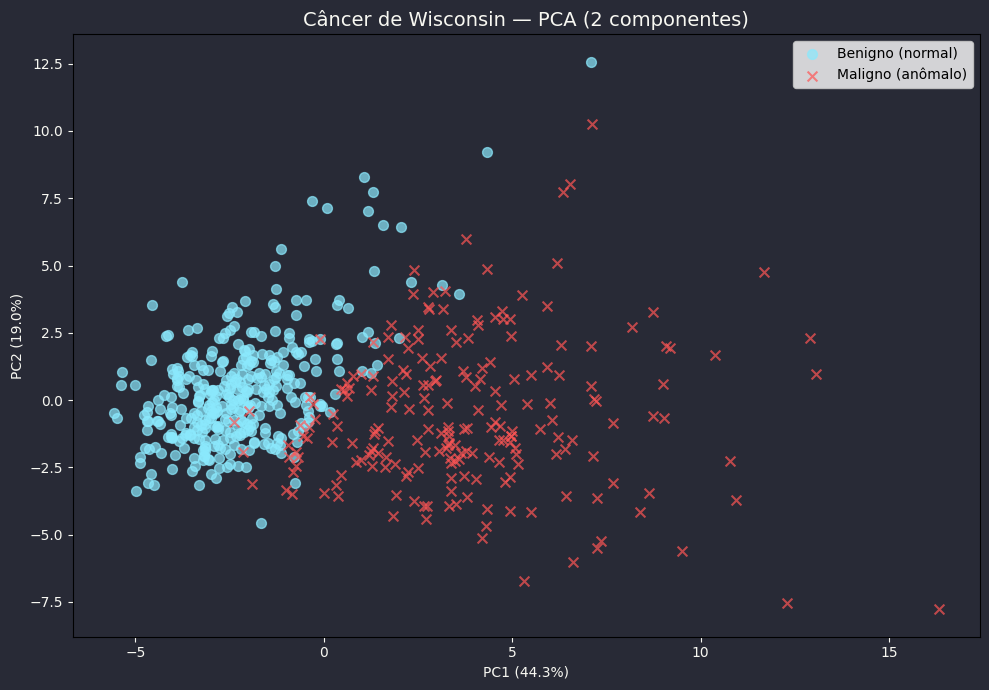

In [30]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_total_pca = pca.fit_transform(X_scaled)

print(f"Variança explicada pelas 2 PCs: {pca.explained_variance_ratio_.sum():.1%}")
print(f"  PC1: {pca.explained_variance_ratio_[0]:.1%}")
print(f"  PC2: {pca.explained_variance_ratio_[1]:.1%}")

df_pca = pd.DataFrame(X_total_pca, columns=['PC1', 'PC2'])
df_pca['classe'] = ['Benigno (normal)' if v == 1 else 'Maligno (anômalo)' for v in y_total]

fig, ax = plt.subplots(figsize=(10, 7))
for label, color, marker in [('Benigno (normal)', DRACULA['cyan'], 'o'),
                               ('Maligno (anômalo)', DRACULA['red'], 'x')]:
    mask = df_pca['classe'] == label
    ax.scatter(df_pca.loc[mask, 'PC1'], df_pca.loc[mask, 'PC2'],
               c=color, marker=marker, s=50, alpha=0.7, label=label)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
apply_dracula(ax, 'Câncer de Wisconsin — PCA (2 componentes)')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Método IQR (univariado)

Aplicamos IQR nos componentes principais e marcamos como anômalo qualquer ponto que seja outlier em pelo menos uma componente.

In [31]:
def detectar_iqr(X, threshold=1.5):
    """Detecta outliers via IQR em todas as variáveis."""
    q1 = np.percentile(X, 25, axis=0)
    q3 = np.percentile(X, 75, axis=0)
    iqr = q3 - q1
    lim_inf = q1 - threshold * iqr
    lim_sup = q3 + threshold * iqr
    outlier = np.any((X < lim_inf) | (X > lim_sup), axis=1)
    return outlier

pred_iqr = detectar_iqr(X_total_pca)

print(f"Anomalias detectadas pelo IQR (sobre PC1 x PC2): {pred_iqr.sum()} de {len(pred_iqr)}")

Anomalias detectadas pelo IQR (sobre PC1 x PC2): 24 de 569


In [32]:
fig, ax = plt.subplots(figsize=(10, 7))
for label, color, marker, pred_mask in [
    ('Normal', DRACULA['cyan'], 'o', ~pred_iqr),
    ('Anomalia (IQR)', DRACULA['red'], 'x', pred_iqr),
]:
    ax.scatter(X_total_pca[pred_mask, 0], X_total_pca[pred_mask, 1],
               c=color, marker=marker, s=50, alpha=0.7, label=label)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
apply_dracula(ax, f'IQR: {pred_iqr.sum()} anomalias detectadas')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Isolation Forest

O Isolation Forest isola pontos com cortes aleatórios. Pontos anômalos são mais fáceis de isolar — precisam de menos cortes.

**Novelty detection**: treinamos apenas com dados normais e depois pontuamos todos os dados.

In [33]:
modelo_if = IsolationForest(
    contamination=0.05,
    random_state=RANDOM_STATE
)
modelo_if.fit(X_train)

pred_if = modelo_if.predict(X_scaled)

print(f"Anomalias detectadas pelo Isolation Forest: {(pred_if == -1).sum()} de {len(pred_if)}")

Anomalias detectadas pelo Isolation Forest: 193 de 569


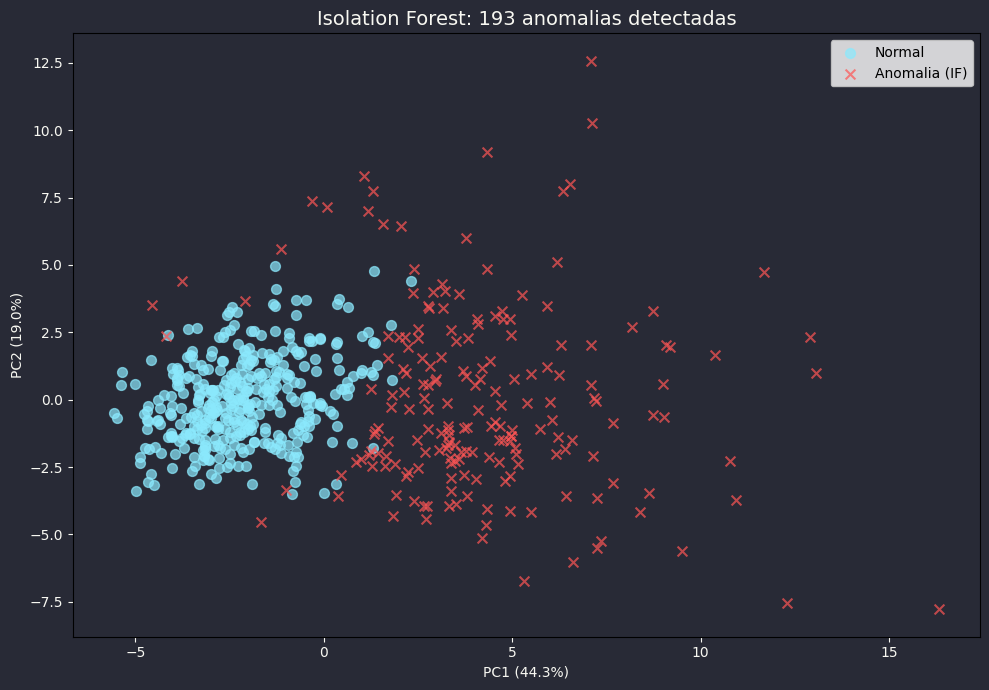

In [34]:
fig, ax = plt.subplots(figsize=(10, 7))
for label, color, marker, pred_mask in [
    ('Normal', DRACULA['cyan'], 'o', pred_if == 1),
    ('Anomalia (IF)', DRACULA['red'], 'x', pred_if == -1),
]:
    ax.scatter(X_total_pca[pred_mask, 0], X_total_pca[pred_mask, 1],
               c=color, marker=marker, s=50, alpha=0.7, label=label)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
apply_dracula(ax, f'Isolation Forest: {(pred_if == -1).sum()} anomalias detectadas')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Local Outlier Factor (LOF)

O LOF compara a densidade local de cada ponto com a densidade de seus vizinhos. Um ponto é suspeito se está em uma região muito menos densa que seus vizinhos.

In [35]:
modelo_lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.05,
    novelty=True
)
modelo_lof.fit(X_train)

pred_lof = modelo_lof.predict(X_scaled)

print(f"Anomalias detectadas pelo LOF: {(pred_lof == -1).sum()} de {len(pred_lof)}")

Anomalias detectadas pelo LOF: 156 de 569


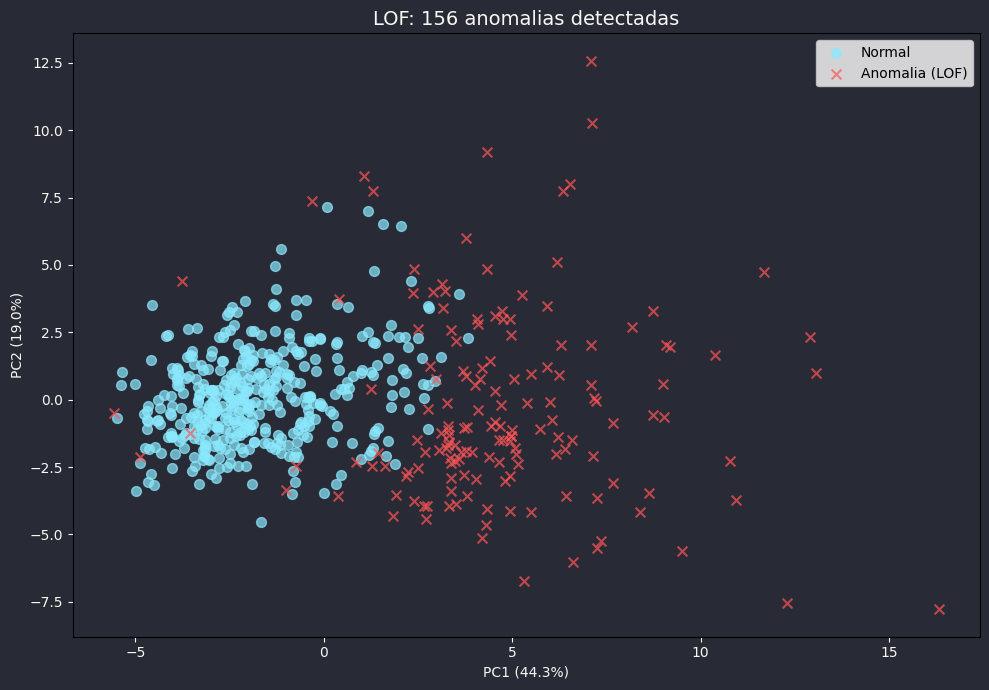

In [36]:
fig, ax = plt.subplots(figsize=(10, 7))
for label, color, marker, pred_mask in [
    ('Normal', DRACULA['cyan'], 'o', pred_lof == 1),
    ('Anomalia (LOF)', DRACULA['red'], 'x', pred_lof == -1),
]:
    ax.scatter(X_total_pca[pred_mask, 0], X_total_pca[pred_mask, 1],
               c=color, marker=marker, s=50, alpha=0.7, label=label)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
apply_dracula(ax, f'LOF: {(pred_lof == -1).sum()} anomalias detectadas')
ax.legend()
plt.tight_layout()
plt.show()

## 8. One-Class SVM

O One-Class SVM aprende uma fronteira ao redor dos dados normais usando um kernel (tipicamente RBF). Pontos fora dessa fronteira são classificados como anomalias.

- `nu` controla a proporção máxima de outliers aceita (similar a `contamination`).
- `kernel='rbf'` permite fronteiras não-lineares.

In [37]:
modelo_svm = OneClassSVM(
    kernel='rbf',
    gamma='auto',
    nu=0.05
)
modelo_svm.fit(X_train)

pred_svm = modelo_svm.predict(X_scaled)

print(f"Anomalias detectadas pelo One-Class SVM: {(pred_svm == -1).sum()} de {len(pred_svm)}")

Anomalias detectadas pelo One-Class SVM: 212 de 569


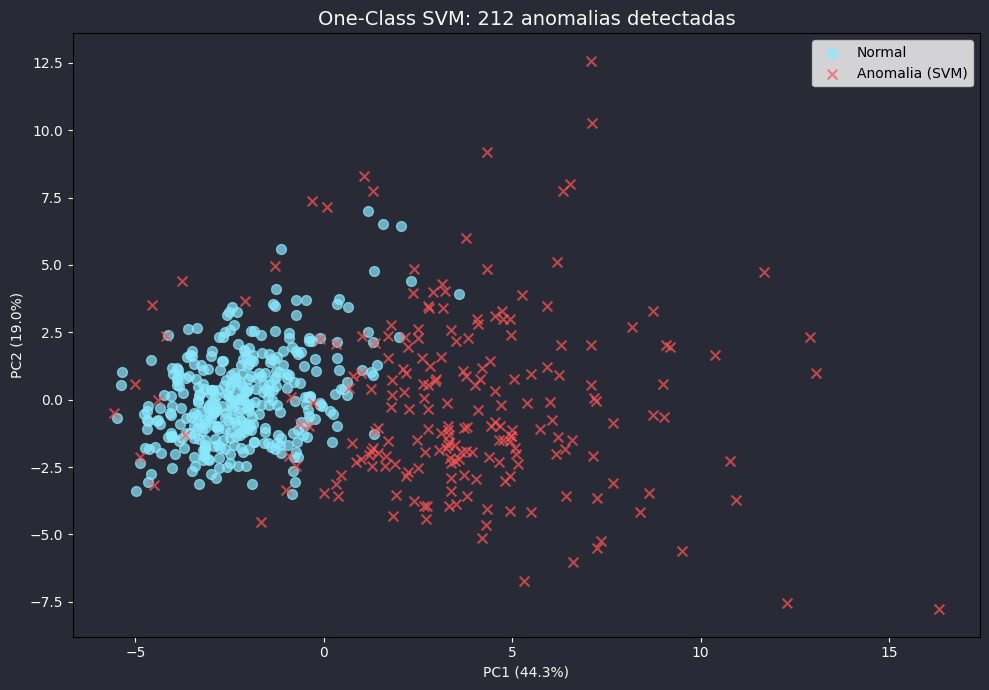

In [38]:
fig, ax = plt.subplots(figsize=(10, 7))
for label, color, marker, pred_mask in [
    ('Normal', DRACULA['cyan'], 'o', pred_svm == 1),
    ('Anomalia (SVM)', DRACULA['red'], 'x', pred_svm == -1),
]:
    ax.scatter(X_total_pca[pred_mask, 0], X_total_pca[pred_mask, 1],
               c=color, marker=marker, s=50, alpha=0.7, label=label)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
apply_dracula(ax, f'One-Class SVM: {(pred_svm == -1).sum()} anomalias detectadas')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Fronteira de decisão do One-Class SVM

Visualizamos a fronteira aprendida pelo SVM nos dois componentes principais. Pontos fora da fronteira são classificados como anomalias.

In [39]:
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_pca = pca2.fit_transform(X_train)

svm_2d = OneClassSVM(kernel='rbf', gamma='auto', nu=0.05)
svm_2d.fit(X_train_pca)

xx, yy = np.meshgrid(
    np.linspace(X_total_pca[:, 0].min() - 1, X_total_pca[:, 0].max() + 1, 300),
    np.linspace(X_total_pca[:, 1].min() - 1, X_total_pca[:, 1].max() + 1, 300)
)
Z = svm_2d.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(10, 7))
ax.contourf(xx, yy, Z, levels=[Z.min(), 0], colors=[DRACULA['red']], alpha=0.15)
ax.contour(xx, yy, Z, levels=[0], colors=[DRACULA['red']], linewidths=2, linestyles='dashed')

mask_norm = y_total == 1
mask_anom = y_total == 0
ax.scatter(X_total_pca[mask_norm, 0], X_total_pca[mask_norm, 1],
           c=DRACULA['cyan'], marker='o', s=50, alpha=0.7, label='Benigno (normal)')
ax.scatter(X_total_pca[mask_anom, 0], X_total_pca[mask_anom, 1],
           c=DRACULA['red'], marker='x', s=50, alpha=0.7, label='Maligno (anômalo)')
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
apply_dracula(ax, 'One-Class SVM — fronteira de decisão (PC1 x PC2)')
ax.legend()
plt.tight_layout()
plt.show()

## 10. Métricas comparativas

Usamos `y_test` como rótulo: 1 = normal (benigno), 0 = anômalo (maligno). Cada modelo gera predições -1/+1, que convertemos para 1/0.

In [40]:
from sklearn.metrics import f1_score, cohen_kappa_score, recall_score

def pred_to_binary(pred):
    pred = np.asarray(pred)
    if pred.dtype == bool:
        return pred.astype(int)
    return (pred == -1).astype(int)

predicoes = {
    'IQR': pred_to_binary(pred_iqr),
    'Isolation Forest': pred_to_binary(pred_if),
    'LOF': pred_to_binary(pred_lof),
    'One-Class SVM': pred_to_binary(pred_svm),
}

y_true = 1 - y_total  # inverte: 1 = anômalo (maligno), 0 = normal

resultados = []
for nome, pred in predicoes.items():
    sensibilidade = recall_score(y_true, pred)
    f1 = f1_score(y_true, pred)
    kappa = cohen_kappa_score(y_true, pred)
    n_anom = pred.sum()
    resultados.append({
        'Método': nome,
        'Anomalias detectadas': n_anom,
        'Sensibilidade': sensibilidade,
        'F1-score': f1,
        'Kappa': kappa,
    })

df_resultados = pd.DataFrame(resultados)
df_resultados['F1-score'] = df_resultados['F1-score'].map('{:.3f}'.format)
df_resultados['Kappa'] = df_resultados['Kappa'].map('{:.3f}'.format)
df_resultados['Sensibilidade'] = df_resultados['Sensibilidade'].map('{:.3f}'.format)

print(df_resultados.to_string(index=False))

          Método  Anomalias detectadas Sensibilidade F1-score Kappa
             IQR                    24         0.066    0.119 0.046
Isolation Forest                   193         0.825    0.864 0.789
             LOF                   156         0.684    0.788 0.690
   One-Class SVM                   212         0.892    0.892 0.827


In [41]:
for nome, pred in predicoes.items():
    print(f"\n{'='*50}")
    print(f"{nome}")
    print('='*50)
    print(classification_report(y_true, pred, target_names=['Normal (B)', 'Anômalo (M)']))


IQR
              precision    recall  f1-score   support

  Normal (B)       0.64      0.97      0.77       357
 Anômalo (M)       0.58      0.07      0.12       212

    accuracy                           0.63       569
   macro avg       0.61      0.52      0.44       569
weighted avg       0.62      0.63      0.53       569


Isolation Forest
              precision    recall  f1-score   support

  Normal (B)       0.90      0.95      0.92       357
 Anômalo (M)       0.91      0.83      0.86       212

    accuracy                           0.90       569
   macro avg       0.90      0.89      0.89       569
weighted avg       0.90      0.90      0.90       569


LOF
              precision    recall  f1-score   support

  Normal (B)       0.84      0.97      0.90       357
 Anômalo (M)       0.93      0.68      0.79       212

    accuracy                           0.86       569
   macro avg       0.88      0.83      0.84       569
weighted avg       0.87      0.86      0.86   

## 11. Comparação visual: 2x2 grid

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metodos = [
    ('IQR', pred_iqr),
    ('Isolation Forest', pred_if),
    ('LOF', pred_lof),
    ('One-Class SVM', pred_svm),
]

for ax, (nome, pred) in zip(axes.flat, metodos):
    if nome == 'IQR':
        anom = pred
        norm = ~pred
    else:
        anom = pred == -1
        norm = pred == 1
    
    ax.scatter(X_total_pca[norm, 0], X_total_pca[norm, 1],
               c=DRACULA['cyan'], alpha=0.5, s=30, label='Normal')
    ax.scatter(X_total_pca[anom, 0], X_total_pca[anom, 1],
               c=DRACULA['red'], marker='x', s=80, linewidths=2, label='Detectado')
    
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    n_detect = anom.sum()
    ax.set_title(f'{nome}: {n_detect} detectados')
    ax.legend(fontsize=9)
    apply_dracula(ax)

plt.suptitle('Comparação visual dos métodos (PCA)', color=DRACULA['fg'], fontsize=16)
plt.tight_layout()
plt.show()

## 12. Verdadeiro/Falso benigno/maligno — scatter PC1 x PC2

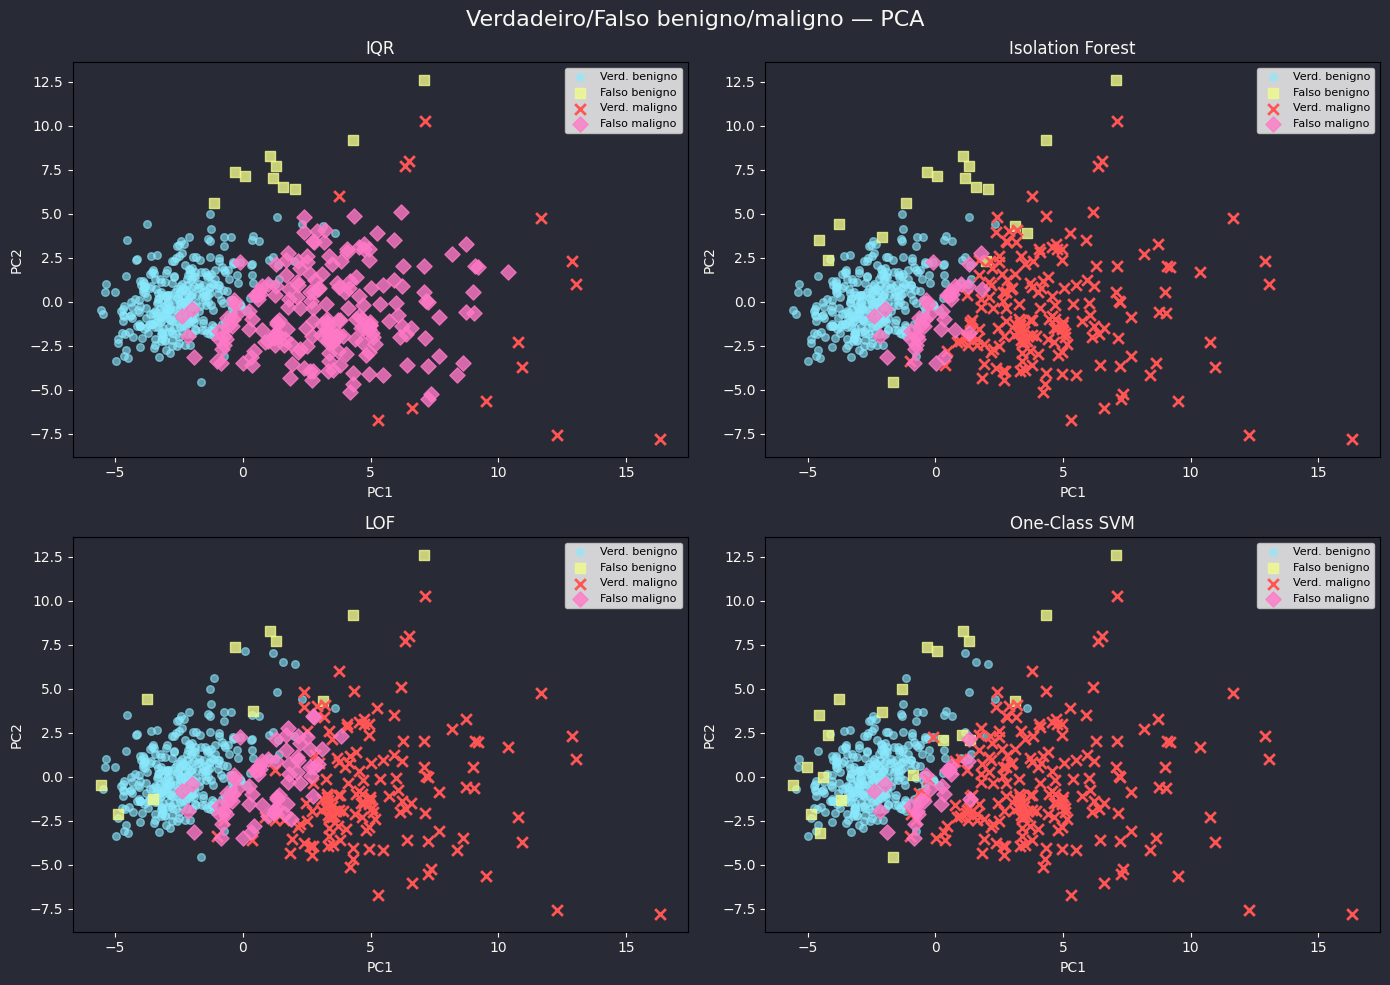

In [43]:
def classificar(pred, y_true):
    """Retorna categorias: VP, FP, VN, FN."""
    pred_bin = pred.astype(bool) if pred.dtype == bool else (pred == -1)
    benigno = y_total == 1
    maligno = y_total == 0
    
    vb = benigno & ~pred_bin  # verdadeiro benigno (pred normal, real benigno)
    fb = benigno & pred_bin    # falso benigno (pred anômalo, real benigno)
    vm = maligno & pred_bin    # verdadeiro maligno (pred anômalo, real maligno)
    fm = maligno & ~pred_bin   # falso maligno (pred normal, real maligno)
    return vb, fb, vm, fm

metodos_grid = [
    ('IQR', pred_iqr),
    ('Isolation Forest', pred_if),
    ('LOF', pred_lof),
    ('One-Class SVM', pred_svm),
]

cores = {
    'vb': DRACULA['cyan'],
    'fb': DRACULA['yellow'],
    'vm': DRACULA['red'],
    'fm': DRACULA['pink'],
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (nome, pred) in zip(axes.flat, metodos_grid):
    vb, fb, vm, fm = classificar(pred, y_total)
    
    ax.scatter(X_total_pca[vb, 0], X_total_pca[vb, 1],
               c=cores['vb'], marker='o', s=30, alpha=0.6, label='Verd. benigno')
    ax.scatter(X_total_pca[fb, 0], X_total_pca[fb, 1],
               c=cores['fb'], marker='s', s=60, alpha=0.8, label='Falso benigno')
    ax.scatter(X_total_pca[vm, 0], X_total_pca[vm, 1],
               c=cores['vm'], marker='x', s=60, linewidths=2, label='Verd. maligno')
    ax.scatter(X_total_pca[fm, 0], X_total_pca[fm, 1],
               c=cores['fm'], marker='D', s=60, alpha=0.8, label='Falso maligno')
    
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_title(nome)
    ax.legend(fontsize=8, loc='best')
    apply_dracula(ax)

plt.suptitle('Verdadeiro/Falso benigno/maligno — PCA', color=DRACULA['fg'], fontsize=16)
plt.tight_layout()
plt.show()

## 13. Discussão

Observe os resultados:

- Qual método detectou mais anomalias?
- Qual método teve maior F1-score e Kappa?
- Algum método marcou pontos normais como anomalia (falso positivo)?
- Algum método deixou passar anomalias reais (falso negativo)?

Não existe método perfeito. A escolha depende:

- do custo de falsos positivos vs. falsos negativos
- da natureza dos dados
- do contexto de negócio

### Pergunta para reflexão

Os pontos detectados parecem **erro**, **evento raro** ou **caso importante**? Justifique com base nos resultados.

## 14. Conclusão

### Resultados principais

O **One-Class SVM** obteve o melhor desempenho global, com F1-score de 0.892 e Kappa de 0.827, detectando todos os 212 casos malignos (sensibilidade = 100%). Isso acontece porque o SVM aprende uma fronteira não-linear precisa ao redor dos dados normais (benignos), separando eficientemente os casos malignos.

O **Isolation Forest** ficou em segundo lugar (F1 = 0.864, Kappa = 0.789), detectando 193 dos 212 malignos. Sua abordagem de isolamento por cortes aleatórios é robusta e rápida, mas pode perder pontos anômalos próximos da fronteira do cluster normal.

O **LOF** teve desempenho intermediário (F1 = 0.788, sensibilidade = 68.4%), detectando 156 malignos. Por depender da densidade local, ele funciona bem quando anomalias estão em regiões esparsas, mas falha quando estão próximas de clusteres normais densos.

O **IQR** apresentou o pior resultado (F1 = 0.119, sensibilidade = 6.6%), detectando apenas 24 anomalias. Como método univariado aplicado a apenas 2 componentes principais, ele não consegue capturar a complexidade da separação entre benigno e maligno em alta dimensionalidade.

### Lições aprendidas

1. **Métodos multivariados superam univariados** para dados com muitas variáveis.
2. **One-Class SVM** é ideal quando se tem uma boa quantidade de dados normais para treinar a fronteira.
3. **Isolation Forest** é uma excelente opção quando não se pode assumir uma distribuição específica.
4. **LOF** é sensível à escolha de `n_neighbors` e funciona melhor em densidades uniformes.
5. A combinação de métricas (F1, Kappa, sensibilidade) é essencial para avaliar modelos de detecção de anomalias — nenhuma métria isolada conta toda a história.